# Augmentation Pipeline

Pipeline to generate augmented images and corresponding labels based on oriented bounding boxes in YOLO-format. So far, it only deals with single-class object detection.

## Imports & Setup

In [1]:
%load_ext autoreload
%autoreload 2
#automatically reload any imported modules when you re-run a cell

In [2]:
import cv2
import albumentations as A
from tqdm import tqdm
from matplotlib import pyplot as plt

from augutils import *

In [4]:
import sys
from pathlib import Path

# Add project root to sys.path (so imports like src.data work)
project_root = Path().cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import DATA_BASE_DIR, logger

seed = 42 #for random image selection & random augmentation

# Pipeline

## Define Augmentations

In [5]:
transform = A.Compose([
 ### A1: Geometric Invariance
        A.Resize(width=1024, height=1024),
        A.Affine(scale=[1,1.2], rotate=[0,90], shear=0, translate_percent=0, keep_ratio=True, p=0.5),
        A.Rotate(limit=90, p=1, border_mode=cv2.BORDER_CONSTANT), #border to be black       
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        ### A2: Occlusion
        A.CoarseDropout(num_holes_range=(1, 8), hole_height_range=(0.1, 0.25),
                    hole_width_range=(0.1, 0.25), p=0.5), #fill_value=0
        ### A3 & A7: ChannelDropout/Greyscale
        A.OneOf([
            A.ToGray(p=1.0), # p=1.0 inside OneOf
            A.ChannelDropout(p=1.0) # p=1.0 inside OneOf
        ], p=0.2), # Apply one of these 20% of the time
        
        ### A4: Color Variation
        A.OneOf([A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.8),            
                 A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.8),            
                 A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.8),            
                 A.RandomGamma(gamma_limit=(80, 120), p=0.8),        
                ], p=0.7),
], keypoint_params=A.KeypointParams(coord_format="xy", remove_invisible=False), seed=seed #remove_invisible=False important to keep right order of bounding box corners
)

## Exmaple with single image

In [6]:
##### MODIFY:
example = "PMOF" # or "CEPDOF

if example == "PMOF":
    #### PMOF
    data_base_dir = DATA_BASE_DIR
    example_image_id = 'rec9_001032'  #Example image_id to demonstrate pipeline, image shows 4 people
    logger.info(f"Selected {example}")
    
if example == "CEPDOF":
    #### CEPDOF
    data_base_dir = "/home/stella/computer_vision/fisheye_data/augmentation_study"
    example_image_id = 'Lunch3_000101' #'ownrec2_000096' #Example image_id to demonstrate pipeline, image shows 2 people
    logger.info(f"Selected {example}")
    
if example != "CEPDOF" and example != "PMOF":
    logger.warning("Select PMOF or CEPDOF as an example")

09:58:09 | INFO | Selected PMOF


### Load Example Image & Label

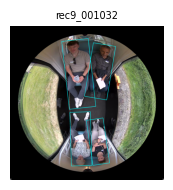

In [7]:
visualize_image_ids(data_base_dir, [example_image_id])

### Apply augmentation one time and visualize

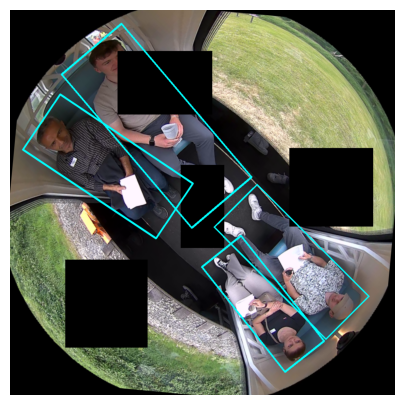

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], shape=(1024, 1024, 3), dtype=uint8)

In [8]:
# Get paths for image_id
paths = get_image_and_label_paths(data_base_dir=data_base_dir, image_id=example_image_id)
example_image_path = paths["image_path"]
example_label_path = paths["label_path"]

# Read image as array and bboxes
image_array = cv2.imread(example_image_path)
h, w = get_image_size(example_image_path) #needed to scale bbox
bboxes = scaled_bbox_from_file(example_label_path, h, w)

# Apply transformation
transformed_image, transformed_bboxes = apply_transformation(image_array, bboxes, transform)

# Visualize
visualize_image_with_bbox(transformed_image, transformed_bboxes, show=True)

### Apply augmentation multiple times and visualize

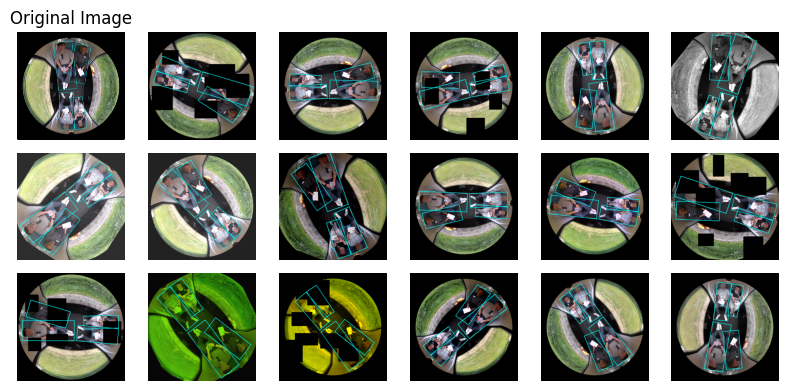

In [9]:
fig = plt.figure(figsize=(8,4))
columns = 6
rows = 3

# Plot original image.
img = visualize_image_with_bbox(image_array, bboxes, show=False)
fig.add_subplot(rows, columns, 1)
plt.imshow(img)
plt.title('Original Image')
plt.axis('off')

for i in range(2, columns*rows+1):
    #transform image multiple times
    transformed_image, transformed_bboxes = apply_transformation(image_array, bboxes, transform)
    img = visualize_image_with_bbox(transformed_image, transformed_bboxes, show=False)
    fig.add_subplot(rows, columns, i)
    plt.imshow(img)
    plt.axis('off')
    
plt.tight_layout()
#plt.savefig('tranformation-samples.png', bbox_inches='tight')
plt.show()    

## Pipeline: Multiple Image Ids

We randomly select image_id from a selection of directories.

In [ ]:
dataset_to_augment = "PMOF" ## "PMOF" or "CEPDOF"
aug_suffix = "a18"
percentage = 25
number_transformations = 2

In [11]:
if dataset_to_augment == "PMOF":
    data_base_dir = '/home/stella/computer_vision/PMOF'
    aug_data_base_dir = '/home/stella/computer_vision/PMOF_aug'
    dirs = [f'{data_base_dir}/images/rec{str(i)}' for i in range(1,26)]
    random_ids = get_random_image_ids(dirs=dirs, percentage=percentage, seed=seed)
    logger.info(f'Augmenting {dataset_to_augment}, randomly selected {len(random_ids)} image_ids to transform ({percentage}%)')
    
if dataset_to_augment == "CEPDOF":
    data_base_dir = '/home/stella/computer_vision/fisheye_data'
    aug_data_base_dir = '/home/stella/computer_vision/fisheye_data/augmentation_study'
    dirs = [f'{data_base_dir}/images/Lunch1', f'{data_base_dir}/images/Lunch2', f'{data_base_dir}/images/Lunch3', 
            f'{data_base_dir}/images/All_off', f'{data_base_dir}/images/High_activity', 
            f'{data_base_dir}/images/IRfilter', f'{data_base_dir}/images/IRill', f'{data_base_dir}/images/Edge_cases']
    random_ids = get_random_image_ids(dirs=dirs, percentage=percentage, seed=seed)
    logger.info(f'Augmenting {dataset_to_augment}, randomly selected {len(random_ids)} image_ids to transform ({percentage}%)')
    
if dataset_to_augment != "CEPDOF" and dataset_to_augment != "PMOF":
    logger.warning("Select PMOF or CEPDOF as an dataset_to_augment")

10:01:50 | INFO | Augmenting PMOF, randomly selected 152 image_ids to transform (1%)


In [12]:
random_ids

['rec1_002835',
 'rec1_002719',
 'rec1_003055',
 'rec1_003270',
 'rec1_002833',
 'rec1_002766',
 'rec1_003114',
 'rec1_002940',
 'rec2_003394',
 'rec2_003656',
 'rec2_003412',
 'rec2_003351',
 'rec2_003318',
 'rec2_003398',
 'rec2_003116',
 'rec2_003197',
 'rec3_000927',
 'rec3_001593',
 'rec3_000885',
 'rec3_001525',
 'rec3_001338',
 'rec3_000722',
 'rec3_001469',
 'rec3_001389',
 'rec3_000852',
 'rec4_001259',
 'rec4_001563',
 'rec4_000877',
 'rec4_001544',
 'rec4_001689',
 'rec4_001124',
 'rec4_000952',
 'rec4_000886',
 'rec5_001183',
 'rec5_001633',
 'rec5_001646',
 'rec5_001120',
 'rec5_001194',
 'rec5_001143',
 'rec5_001409',
 'rec5_001532',
 'rec6_002201',
 'rec6_002152',
 'rec6_001823',
 'rec6_002294',
 'rec6_001916',
 'rec6_002426',
 'rec6_001933',
 'rec6_002425',
 'rec7_001585',
 'rec7_001499',
 'rec7_001428',
 'rec7_001502',
 'rec7_001872',
 'rec7_002050',
 'rec7_001414',
 'rec7_001627',
 'rec8_000861',
 'rec8_001573',
 'rec8_000919',
 'rec8_001660',
 'rec8_000790',
 'rec8_0

### Now the Full Pipeline

Now we use the full augmentation & saving pipeline to transform each of the randomly selected images a set number of times, save the resulting images and labels and record the image_ids of these transformed images to plot in the second step.

In [13]:
for image_id in tqdm(random_ids):
    transformed_ids = augmentation_saving_pipeline(data_base_dir=data_base_dir, aug_suffix=aug_suffix,
                                                   image_id=image_id, 
                                                   number_transformations=number_transformations, transform=transform, aug_data_base_dir=aug_data_base_dir)

100%|██████████| 152/152 [00:15<00:00,  9.93it/s]
